## Clasificación de MRI con Redes Neuronales Convolucionales para Tipos de Cáncer




Se requiere realizar un modelo Deep Learning usando redes neuronales convolucionales CNN, para la clasificación de imagenes de resonancia magnética del cerebro y determinar si la imagén es de una de estás 4 categorías de tipo de cáncer: glioma, meningioma, pituitary (hipófisis) o tejido sano.

Para lograr este modelo se realizarán los siguientes pasos:

1. Importar las librerías necesarias.
2. Realizar extracción de los datos y analisis descriptivo.
3. División del dataset en entrenamiento, validación y prueba
4. Entrenar un modelo CNN con diferentes parámetros para encontrar el mejor modelo.
5. Evaluar la precisión del modelo.
6. Análisis de resultados.

## Objetivo
  * Realizar un modelo de clasificación para imagenes de resonancia magnética y determinar el tipo de cáncer.



## 1. Importación de las librerías requeridas

Se importan librerías como:
* kagglehub: usada para exportar la base de datos de imagenes de resonancia.
* tensorflow: usada para crear el modelo de red neuronal de convolución con la cual se va a crear el modelo de clasificación.
* sklearn: usada para analisar el rendimiento del modelo.
* matplotlib: usada para realizar analisis de los datos a través de graficas.

In [2]:
! pip install visualkeras
! pip install keras_tuner
! pip install kagglehub


[notice] A new release of pip is available: 23.3.2 -> 25.0.1
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip is available: 23.3.2 -> 25.0.1
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip is available: 23.3.2 -> 25.0.1
[notice] To update, run: python -m pip install --upgrade pip


In [17]:
import pandas as pd
import kagglehub
import os
import random
from collections import Counter
from PIL import Image
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras import layers, models
import visualkeras
import keras_tuner as kt
from keras_tuner.tuners import RandomSearch


# 2. Extracción de los datos y análisis descriptivo.

Ruta donde se encuentran los datos.

In [4]:
# Descargar última versión del dataset con la API de Kaggle
data_dir = kagglehub.dataset_download("rm1000/brain-tumor-mri-scans")

print("Path to dataset files:", data_dir)
data_dir

Path to dataset files: /root/.cache/kagglehub/datasets/rm1000/brain-tumor-mri-scans/versions/1


'/root/.cache/kagglehub/datasets/rm1000/brain-tumor-mri-scans/versions/1'

Se crea la función `plot_combined_class_distribution` para graficar el dataset y observar la distribución de los datos para las diferentes categorías.

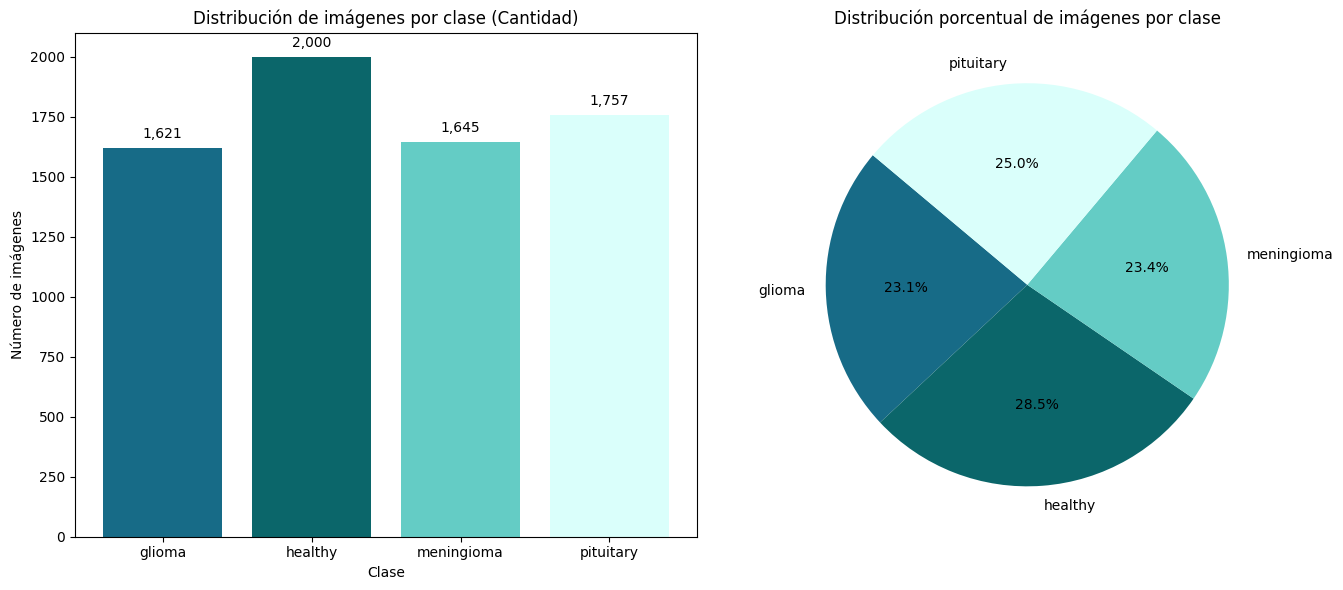

In [5]:
def plot_combined_class_distribution(data_dir):
    class_counts = {}

    for class_name in sorted(os.listdir(data_dir)):
        class_path = os.path.join(data_dir, class_name)
        if os.path.isdir(class_path):
            image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.png'))]
            class_counts[class_name] = len(image_files) #se obtiene la cantidad de registros que hay por categoría

    labels = list(class_counts.keys())
    counts = list(class_counts.values())



    colors = ['#176B87', '#0B666A', '#64CCC5', '#DAFFFB']
    color_map = {label: colors[i % len(colors)] for i, label in enumerate(labels)}
    class_colors = [color_map[label] for label in labels]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Gráfico de barras
    bars = axes[0].bar(labels, counts, color=class_colors)
    axes[0].set_title("Distribución de imágenes por clase (Cantidad)")
    axes[0].set_xlabel("Clase")
    axes[0].set_ylabel("Número de imágenes")


    # Etiquetas
    for bar in bars:
        height = bar.get_height()
        axes[0].annotate("{:,.0f}".format(int(height)),
                         xy=(bar.get_x() + bar.get_width() / 2, height),
                         xytext=(0, 5),
                         textcoords="offset points",
                         ha='center', va='bottom',
                         fontsize=10, color='black')

    # Pie chart con porcentajes
    wedges, texts, autotexts = axes[1].pie(
        counts, labels=labels, autopct='%1.1f%%', startangle=140,
        colors=class_colors, textprops={'fontsize': 10}
    )
    axes[1].set_title("Distribución porcentual de imágenes por clase")

    plt.tight_layout()
    plt.show()


plot_combined_class_distribution(data_dir)

En las imágenes anteriores se puede visualizar que las clases están relativamente balanceadas.

Se revisa la cantidad de de imagenes que hay por dimensiones.

In [6]:
def check_image_dimensions(data_dir):
    dimensions = []

    for class_name in os.listdir(data_dir):
        class_path = os.path.join(data_dir, class_name)

        for file in os.listdir(class_path):
            img_path = os.path.join(class_path, file)
            with Image.open(img_path) as img:
                dimensions.append(img.size)  # (width, height)


    dim_counts = Counter(dimensions)

    for dim, count in dim_counts.items():
        print(f"Tamaño {dim}: {count} imágenes")


check_image_dimensions(data_dir)

Tamaño (504, 540): 23 imágenes
Tamaño (276, 326): 17 imágenes
Tamaño (225, 225): 332 imágenes
Tamaño (630, 630): 90 imágenes
Tamaño (232, 217): 50 imágenes
Tamaño (300, 168): 49 imágenes
Tamaño (208, 242): 24 imágenes
Tamaño (150, 198): 44 imágenes
Tamaño (201, 250): 29 imágenes
Tamaño (234, 218): 7 imágenes
Tamaño (236, 236): 81 imágenes
Tamaño (428, 417): 42 imágenes
Tamaño (209, 234): 2 imágenes
Tamaño (339, 340): 13 imágenes
Tamaño (411, 501): 2 imágenes
Tamaño (228, 221): 51 imágenes
Tamaño (550, 664): 16 imágenes
Tamaño (350, 393): 7 imágenes
Tamaño (236, 295): 6 imágenes
Tamaño (235, 261): 3 imágenes
Tamaño (201, 251): 58 imágenes
Tamaño (642, 361): 22 imágenes
Tamaño (212, 238): 12 imágenes
Tamaño (236, 213): 19 imágenes
Tamaño (444, 506): 1 imágenes
Tamaño (200, 248): 3 imágenes
Tamaño (205, 249): 3 imágenes
Tamaño (227, 222): 39 imágenes
Tamaño (230, 282): 17 imágenes
Tamaño (680, 680): 15 imágenes
Tamaño (192, 192): 31 imágenes
Tamaño (229, 280): 1 imágenes
Tamaño (215, 234)

Gráficas aleatorias de imagenes por clase

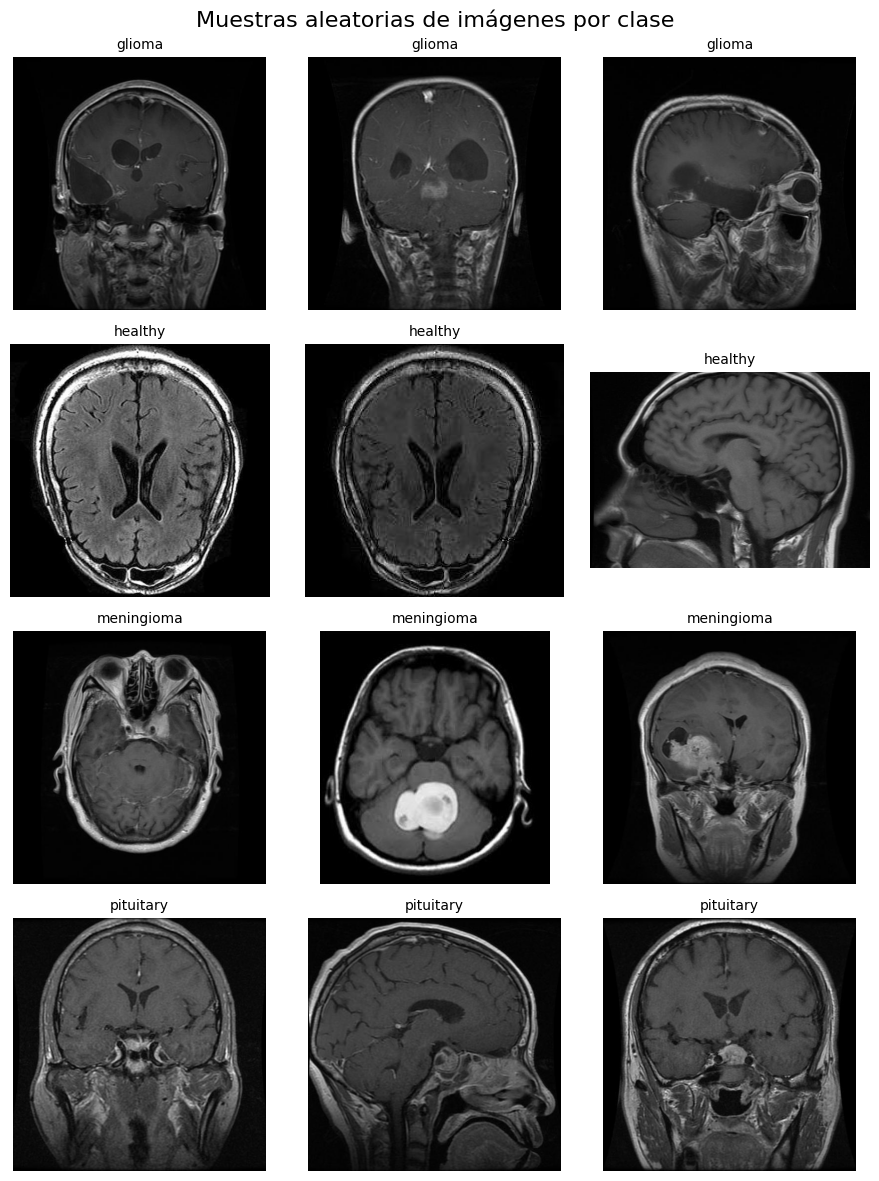

In [7]:
def display_random_images_per_class(data_dir, images_per_class=3):
    classes = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])
    fig, axes = plt.subplots(len(classes), images_per_class, figsize=(images_per_class * 3, len(classes) * 3))

    for i, class_name in enumerate(classes):
        class_path = os.path.join(data_dir, class_name)
        images = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.png'))]
        selected_images = random.sample(images, min(images_per_class, len(images)))

        for j, img_name in enumerate(selected_images):
            img_path = os.path.join(class_path, img_name)
            img = Image.open(img_path)
            ax = axes[i][j] if len(classes) > 1 else axes[j]
            ax.imshow(img)
            ax.axis('off')
            ax.set_title(class_name, fontsize=10)

    plt.suptitle("Muestras aleatorias de imágenes por clase", fontsize=16)
    plt.tight_layout()
    plt.show()


display_random_images_per_class(data_dir)

# 3. División del dataset en Entrenamiento, Validación y Prueba

Carga de los datos y separación de entrenamiento, validación y prueba. Se utilizará 80% para validación, 10% para validación y 10% para prueba.

In [8]:
# Parametros
SEED = 42
IMAGE_SIZE = (112, 112)
BATCH_SIZE = 32
EPOCHS = 40
AUTOTUNE = tf.data.AUTOTUNE


# Carga del dataset de entrenamiento (80%)
train_ds = image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset='training',
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)



# Se carga un dataset temporal para luego hacer la partición entre validación y prueba
temp_ds = image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset='validation',
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

# Split temp_ds into val (10%) and test (10%)
temp_batches = tf.data.experimental.cardinality(temp_ds).numpy()
val_ds = temp_ds.take(temp_batches // 2)
test_ds = temp_ds.skip(temp_batches // 2)


class_names = train_ds.class_names
print("Clases:", class_names)

# Prefetch para mejorar el rendimiento del entrenamiento

# Almacena en caché el conjunto de entrenamiento en memoria, lo mezcla (shuffle) para mejorar el aprendizaje
# y precarga (prefetch) los lotes siguientes mientras el modelo entrena con el lote actual.
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)

# Almacena en caché el conjunto de validación y también precarga los lotes para acelerar la validación.
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# Almacena en caché el conjunto de prueba y precarga los lotes para agilizar la evaluación final.
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)



Found 7023 files belonging to 4 classes.
Using 5619 files for training.
Found 7023 files belonging to 4 classes.
Using 1404 files for validation.
Clases: ['glioma', 'healthy', 'meningioma', 'pituitary']


## 4. Creación y entrenamiento del modelo de Deep Learning CNN.

Se define la función `create_model` para crear el modelo CNN. Se realizará una búsqueda aleatoria de hiperparámetros por medio de la librería `keras_tuner` buscando entre 2 y 4 capas convolucionales, entre 32 y 256 kernels, una capa densa con entre 64 y 512 unidades y una taza de aprendizaje entre 1e-4 y 1e-2 utilizada en el optimizador Adam.

In [9]:
def create_model(hp):
    model = models.Sequential()

    # Normaliza los valores de la imagen al rango [0, 1]
    model.add(layers.Rescaling(1./255, input_shape=(112, 112, 3)))

    for i in range(hp.Int('num_conv_layers', 2, 4)):
        filters = hp.Choice(f'conv_{i}_filters', values=[32, 64, 128, 256])
        model.add(layers.Conv2D(filters, kernel_size=3, activation='relu', padding='same'))
        model.add(layers.MaxPooling2D(pool_size=2))

    # Aplana la salida para conectarla a la capa densa
    model.add(layers.Flatten())

    # Número de neuronas en la capa densa entre 64 y 512
    dense_units = hp.Int('dense_units', min_value=64, max_value=512, step=64)
    model.add(layers.Dense(dense_units, activation='relu'))

    # Dropout para evitar sobreajuste, entre 0.0 y 0.5
    dropout_rate = hp.Float('dropout_rate', min_value=0.0, max_value=0.5, step=0.1)
    if dropout_rate > 0:
        model.add(layers.Dropout(dropout_rate))

    # Capa de salida para clasificación multiclase (4 clases)
    model.add(layers.Dense(4, activation='softmax'))

    # Tuning del learning rate (escala logarítmica)
    learning_rate = hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='log')

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(optimizer=optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    return model

A continuación se define la búsqueda aleatoria de hiperparámetros, se harán 10 trials, se hará una parada temprana si luego de 3 ejecuciones no mejora la métrica de `val_loss`se parará la ejecución, finalmente se escogerá el modelo que tenga el mayor accuracy en validación.

In [10]:
tuner = RandomSearch(
    create_model,
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=1,
    directory='tuning_logs',
    project_name='tumor_model_v4'
)

# Parada temprana si la métrica no mejora
stop_early = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3
)

tuner.search(train_ds,
             validation_data=val_ds,
             epochs=EPOCHS,
             callbacks=[stop_early])


# Extrae el mejor modelo encontrado
best_model = tuner.get_best_models(num_models=1)[0]

best_model.summary()

Trial 10 Complete [00h 00m 39s]
val_accuracy: 0.9261363744735718

Best val_accuracy So Far: 0.9616477489471436
Total elapsed time: 00h 06m 24s
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling (Rescaling)       (None, 112, 112, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 112, 112, 64)      1792      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 56, 56, 64)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 56, 56, 32)        18464     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 28, 28, 32)       0         
 2D)                                         

Se utliza la librería `visualkeras`para representar el modelo obtenido

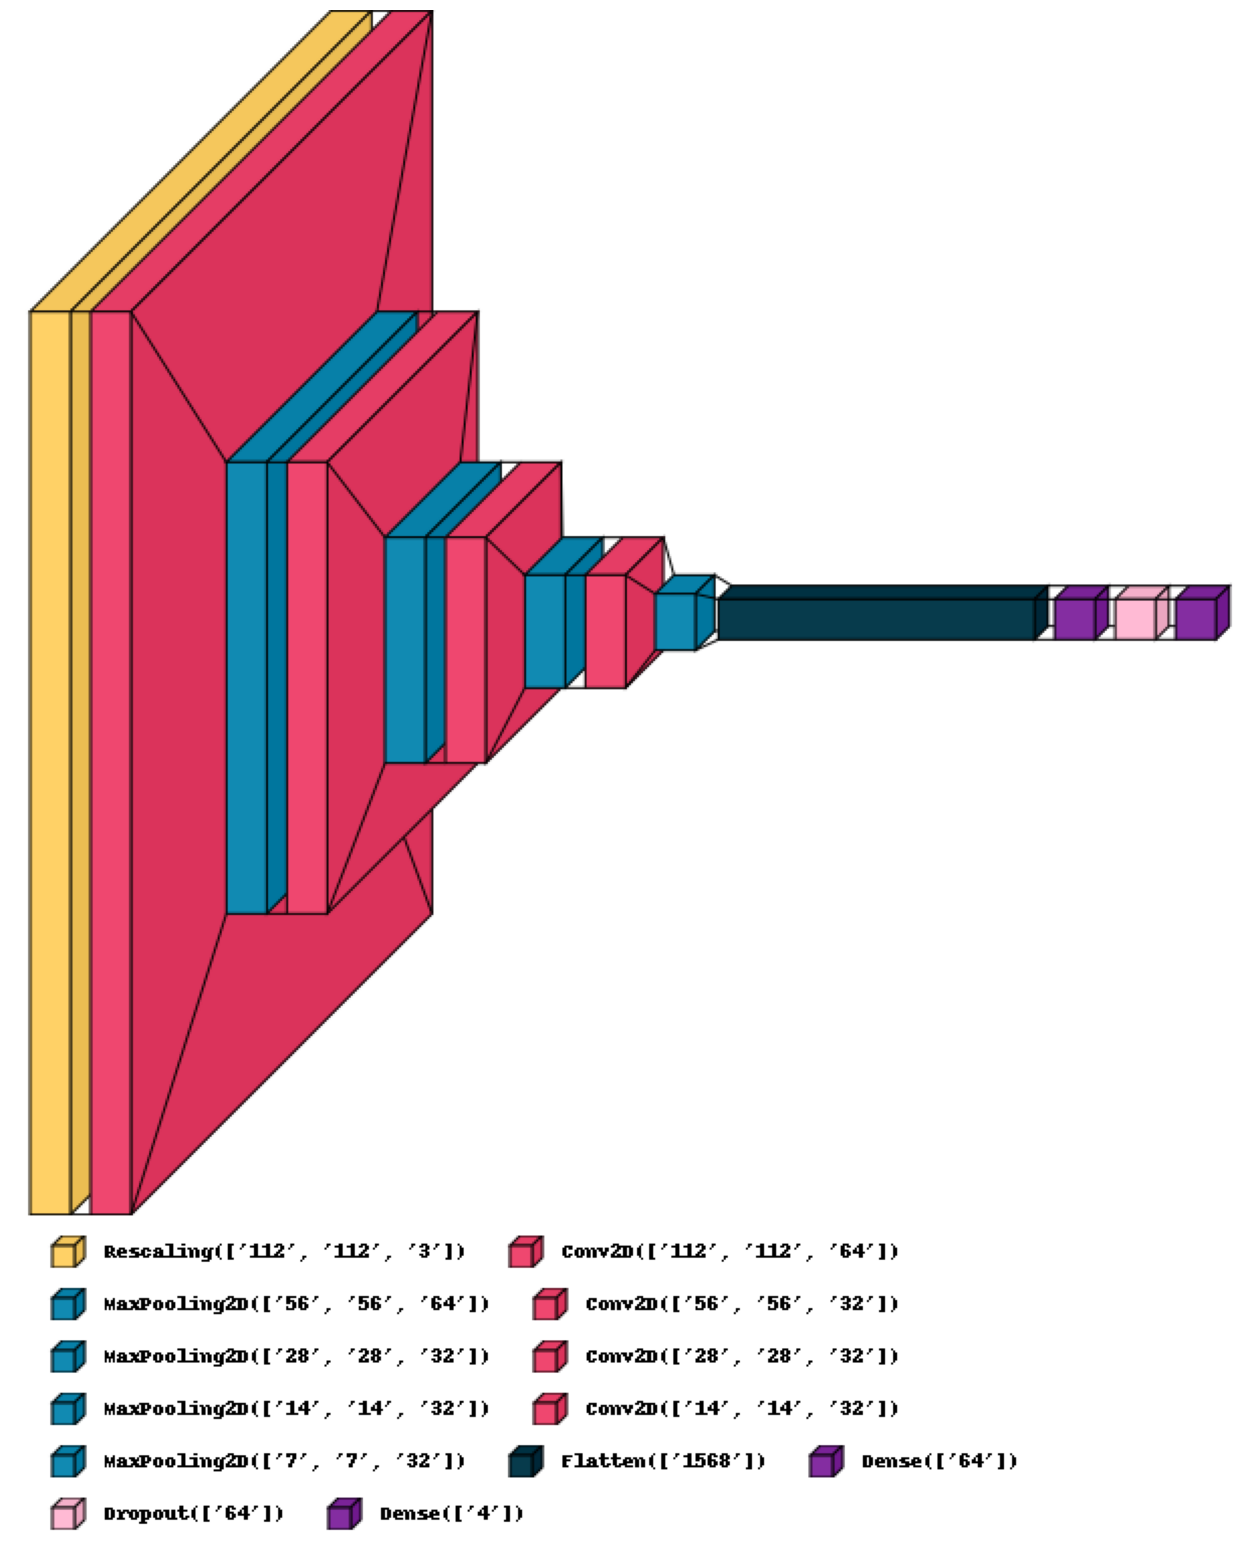

In [11]:
img = visualkeras.layered_view(best_model, legend=True, show_dimension=True)

plt.figure(figsize=(20, 20))
plt.imshow(img)
plt.axis('off')
plt.show()

# 5. Evaluación del modelo obtenido

In [12]:
history = best_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/40
176/176 [==============================] - 2s 10ms/step - loss: 0.0981 - accuracy: 0.9619 - val_loss: 0.2411 - val_accuracy: 0.9489
Epoch 2/40
176/176 [==============================] - 2s 10ms/step - loss: 0.0846 - accuracy: 0.9694 - val_loss: 0.2232 - val_accuracy: 0.9446
Epoch 3/40
176/176 [==============================] - 2s 10ms/step - loss: 0.0754 - accuracy: 0.9712 - val_loss: 0.2664 - val_accuracy: 0.9418
Epoch 4/40
176/176 [==============================] - 2s 10ms/step - loss: 0.0693 - accuracy: 0.9740 - val_loss: 0.3170 - val_accuracy: 0.9304
Epoch 5/40
176/176 [==============================] - 2s 10ms/step - loss: 0.0759 - accuracy: 0.9735 - val_loss: 0.2824 - val_accuracy: 0.9517
Epoch 6/40
176/176 [==============================] - 2s 9ms/step - loss: 0.0649 - accuracy: 0.9769 - val_loss: 0.2752 - val_accuracy: 0.9432
Epoch 7/40
176/176 [==============================] - 2s 10ms/step - loss: 0.0773 - accuracy: 0.9708 - val_loss: 0.2563 - val_accuracy: 0.9574


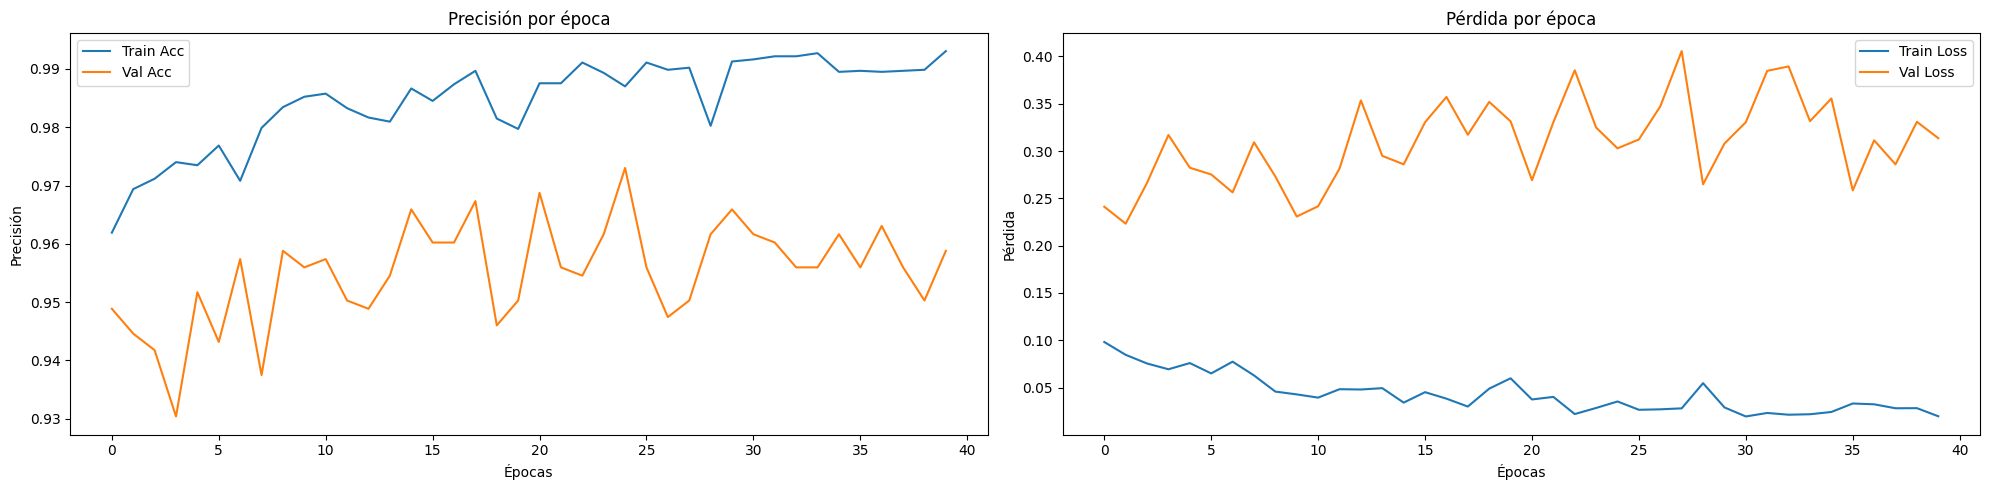

In [13]:
def plot_training_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(len(acc))

    plt.figure(figsize=(20, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label='Train Acc')
    plt.plot(epochs, val_acc, label='Val Acc')
    plt.title('Precisión por época')
    plt.xlabel('Épocas')
    plt.ylabel('Precisión')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label='Train Loss')
    plt.plot(epochs, val_loss, label='Val Loss')
    plt.title('Pérdida por época')
    plt.xlabel('Épocas')
    plt.ylabel('Pérdida')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_training_history(history)

# 6. Análisis de resultados

1/1 [==============================] - 0s 23ms/step

Classification Report:
              precision    recall  f1-score   support

      glioma     0.9408    0.9533    0.9470       150
     healthy     0.9852    0.9709    0.9780       206
  meningioma     0.9130    0.9363    0.9245       157
   pituitary     0.9891    0.9733    0.9811       187

    accuracy                         0.9600       700
   macro avg     0.9570    0.9584    0.9577       700
weighted avg     0.9606    0.9600    0.9602       700



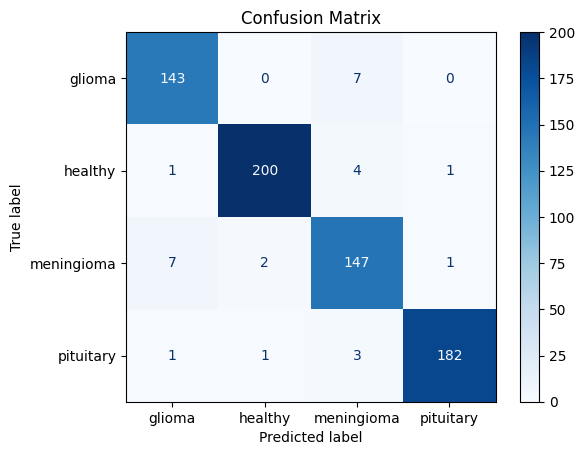

In [18]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = best_model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# Reporte de clasificación con métricas de precisión, recall y f1-score
print("\nClassification Report:")
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print(report)

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()
